In [1]:
import numpy as np
import pandas as pd
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,matthews_corrcoef

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

In [2]:
df = pd.read_csv('../Feature Engineering/EPL_Final_cleaned_features_v2.csv')
df.head(5)

,Temperature,Humidity,WindDirection,Precipitation,WindSpeed,Home_Prv_FTHG,Home_Prv_HS,Home_Prv_HST,Home_Prv_HF,Home_Prv_HC,...,WeatherCode_Clear,WeatherCode_Clouds,WeatherCode_Drizzle,WeatherCode_Fog,WeatherCode_Haze,WeatherCode_Mist,WeatherCode_Rain,WeatherCode_Snow,Time_of_Day_Afternoon,Time_of_Day_Evening
0,1.589044,-0.947690,0.173322,-0.362486,1.677221,0.561811,0.043716,-0.045927,-0.171534,0.002643,...,0,1,0,0,0,0,0,0,1,0
1,1.917548,-0.815443,0.500378,-0.362486,1.280300,1.363757,2.156421,1.555162,-0.443552,1.065042,...,1,0,0,0,0,0,0,0,1,0
2,1.400248,-0.418701,0.816532,-0.362486,0.273563,0.561811,-0.340412,-0.846471,-1.259605,-0.351490,...,0,1,0,0,0,0,0,0,1,0
3,1.811823,-0.683196,0.500378,-0.362486,0.558625,0.561811,-1.300732,-0.446199,2.004609,-1.413890,...,0,0,0,0,0,0,1,0,1,0
4,2.011946,-0.881566,0.500378,-0.362486,0.558625,1.363757,0.811972,2.355707,0.100484,0.710909,...,1,0,0,0,0,0,0,0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                1072 non-null   float64
 1   Humidity                   1072 non-null   float64
 2   WindDirection              1072 non-null   float64
 3   Precipitation              1072 non-null   float64
 4   WindSpeed                  1072 non-null   float64
 5   Home_Prv_FTHG              1072 non-null   float64
 6   Home_Prv_HS                1072 non-null   float64
 7   Home_Prv_HST               1072 non-null   float64
 8   Home_Prv_HF                1072 non-null   float64
 9   Home_Prv_HC                1072 non-null   float64
 10  Home_Prv_HY                1072 non-null   float64
 11  Home_Prv_HR                1072 non-null   float64
 12  Away_Prv_FTAG              1072 non-null   float64
 13  Away_Prv_AS                1072 non-null   float

In [4]:
train_data = df[df['season'].isin(['2019-2020', '2020-2021'])]
test_data = df[df['season'] == '2021-2022']

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 722 entries, 0 to 721
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                722 non-null    float64
 1   Humidity                   722 non-null    float64
 2   WindDirection              722 non-null    float64
 3   Precipitation              722 non-null    float64
 4   WindSpeed                  722 non-null    float64
 5   Home_Prv_FTHG              722 non-null    float64
 6   Home_Prv_HS                722 non-null    float64
 7   Home_Prv_HST               722 non-null    float64
 8   Home_Prv_HF                722 non-null    float64
 9   Home_Prv_HC                722 non-null    float64
 10  Home_Prv_HY                722 non-null    float64
 11  Home_Prv_HR                722 non-null    float64
 12  Away_Prv_FTAG              722 non-null    float64
 13  Away_Prv_AS                722 non-null    float64

### Model with Weather Data:

In [6]:
# Splitting into features and target variable
X_train = train_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam'])
y_train = train_data['FTR']
X_test = test_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam'])
y_test = test_data['FTR']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((722, 51), (722,), (350, 51), (350,))

Feature Selection:

In [7]:
model = LogisticRegression()
sfs_rf_results = []

for n_features in range(3, 31, 3):
    start = time()
    # Set up the Sequential Feature Selector
    sfs = SequentialFeatureSelector(model, n_features_to_select=n_features, cv=5, n_jobs=-1)
    
    # Fit the Sequential Feature Selector
    sfs.fit(X_train, y_train)  # Assuming 'class' is the target

    X_sfs = sfs.transform(X_train)

    # Get the selected features
    selected_features = X_train.columns[sfs.get_support()].tolist()
    
    # Get the cross-validated score
    scores = cross_val_score(model, X_train[selected_features], y_train, cv=5)
    
    # Store the results
    sfs_rf_results.append((n_features, scores.mean(), scores.std(), selected_features))
    
    process_time = time() - start
    print(f'Processed {n_features} in: {process_time}s')
    print(f'Result: {n_features},{scores.mean()},{scores.std()},{selected_features}')

# Convert results to a DataFrame for easy viewing
df_sfs_result = pd.DataFrame(sfs_rf_results, columns=['Number of Features', 'Mean CV Score', 'CV Score Std', 'Selected Features'])

df_sfs_result

Processed 3 in: 5.51706600189209s
Result: 3,0.6232375478927203,0.02306555176490775,['Home_Avg_3_HS', 'Home_Prv_3_Win', 'WeatherCode_Clouds']
Processed 6 in: 3.548774480819702s
Result: 6,0.6315613026819923,0.02549933645177702,['Home_Avg_3_HS', 'Home_Avg_3_HF', 'Home_Prv_3_Win', 'WeatherCode_Clouds', 'WeatherCode_Fog', 'WeatherCode_Haze']
Processed 9 in: 5.165740728378296s
Result: 9,0.6288122605363984,0.022032766848286933,['Away_Prv_AR', 'Home_Avg_3_HS', 'Home_Avg_3_HF', 'Home_Prv_3_Win', 'WeatherCode_Clouds', 'WeatherCode_Drizzle', 'WeatherCode_Fog', 'WeatherCode_Haze', 'WeatherCode_Snow']
Processed 12 in: 6.680359601974487s
Result: 12,0.6274233716475096,0.01712930796130557,['WindDirection', 'Away_Prv_AR', 'Home_Avg_3_HS', 'Home_Avg_3_HF', 'Home_Avg_3_HC', 'Away_Avg_3_AR', 'Home_Prv_3_Win', 'WeatherCode_Clouds', 'WeatherCode_Drizzle', 'WeatherCode_Fog', 'WeatherCode_Haze', 'WeatherCode_Snow']
Processed 15 in: 8.125708818435669s
Result: 15,0.6274137931034482,0.034453033697372376,['WindDi

,Number of Features,Mean CV Score,CV Score Std,Selected Features
0,3,0.623238,0.023066,"[Home_Avg_3_HS, Home_Prv_3_Win, WeatherCode_Cl..."
1,6,0.631561,0.025499,"[Home_Avg_3_HS, Home_Avg_3_HF, Home_Prv_3_Win,..."
2,9,0.628812,0.022033,"[Away_Prv_AR, Home_Avg_3_HS, Home_Avg_3_HF, Ho..."
3,12,0.627423,0.017129,"[WindDirection, Away_Prv_AR, Home_Avg_3_HS, Ho..."
4,15,0.627414,0.034453,"[WindDirection, Home_Prv_FTHG, Home_Prv_HR, Aw..."
5,18,0.616351,0.024848,"[WindDirection, Home_Prv_FTHG, Home_Prv_HR, Aw..."
6,21,0.605268,0.024224,"[WindDirection, Precipitation, Home_Prv_FTHG, ..."
7,24,0.601130,0.017843,"[WindDirection, Precipitation, Home_Prv_FTHG, ..."
8,27,0.598285,0.028800,"[WindDirection, Precipitation, Home_Prv_FTHG, ..."
9,30,0.584454,0.031142,"[WindDirection, Precipitation, WindSpeed, Home..."


In [8]:
df_sfs_result = pd.DataFrame(sfs_rf_results, columns=['Number of Features', 'Mean CV Score', 'CV Score Std', 'Selected Features'])

df_sfs_result

,Number of Features,Mean CV Score,CV Score Std,Selected Features
0,3,0.623238,0.023066,"[Home_Avg_3_HS, Home_Prv_3_Win, WeatherCode_Cl..."
1,6,0.631561,0.025499,"[Home_Avg_3_HS, Home_Avg_3_HF, Home_Prv_3_Win,..."
2,9,0.628812,0.022033,"[Away_Prv_AR, Home_Avg_3_HS, Home_Avg_3_HF, Ho..."
3,12,0.627423,0.017129,"[WindDirection, Away_Prv_AR, Home_Avg_3_HS, Ho..."
4,15,0.627414,0.034453,"[WindDirection, Home_Prv_FTHG, Home_Prv_HR, Aw..."
5,18,0.616351,0.024848,"[WindDirection, Home_Prv_FTHG, Home_Prv_HR, Aw..."
6,21,0.605268,0.024224,"[WindDirection, Precipitation, Home_Prv_FTHG, ..."
7,24,0.601130,0.017843,"[WindDirection, Precipitation, Home_Prv_FTHG, ..."
8,27,0.598285,0.028800,"[WindDirection, Precipitation, Home_Prv_FTHG, ..."
9,30,0.584454,0.031142,"[WindDirection, Precipitation, WindSpeed, Home..."


In [9]:
df_sfs_result.to_csv('SequentialFeatureSelector.csv')

In [11]:
rf = RandomForestClassifier(random_state=42)
sfs_2 = SequentialFeatureSelector(rf, n_features_to_select="auto", tol= 0.01, cv=5, n_jobs=-1)
sfs_2.fit(X_train, y_train)  
X_sfs = sfs_2.transform(X_train)

In [14]:
X_train.columns[sfs_2.get_support()].tolist()

['Home_Prv_3_Win']

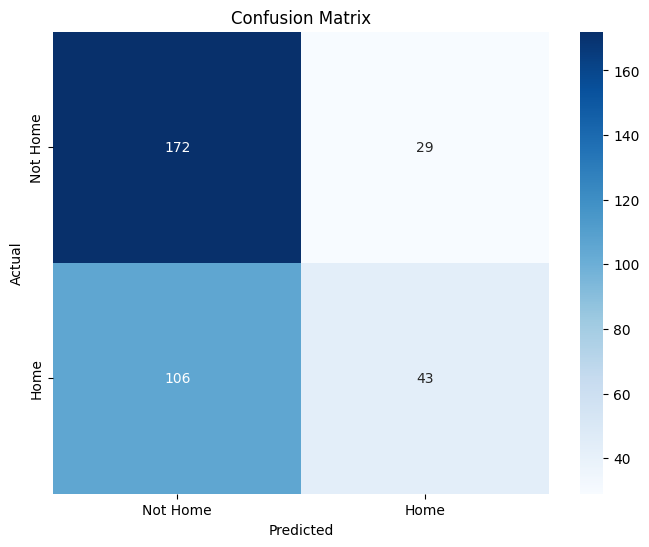

{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
MCC: 0.1765244851286848
accuracy: 0.6142857142857143
              precision    recall  f1-score   support

           0       0.62      0.86      0.72       201
           1       0.60      0.29      0.39       149

    accuracy                           0.61       350
   macro avg       0.61      0.57      0.55       350
weighted avg       0.61      0.61      0.58       350



In [6]:
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': range(3,8),
    'min_samples_split': range(2,9),
    'min_samples_leaf': range(2,9)
    # 'bootstrap': [True, False]
}

# Using GridSearchCV to find the best hyperparameters (with weather data)
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Best parameters from GridSearch
best_params = grid_search_rf.best_params_

# Building the Random Forest model with the best parameters
model_rf = RandomForestClassifier(**best_params, random_state=42)
model_rf.fit(X_train, y_train)

# Predicting on the test data
y_pred = model_rf.predict(X_test)

# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [7]:
pd.DataFrame(y_pred,columns=['LR_y_pred']).to_csv('2.RF_y_pred_with_weather.csv')

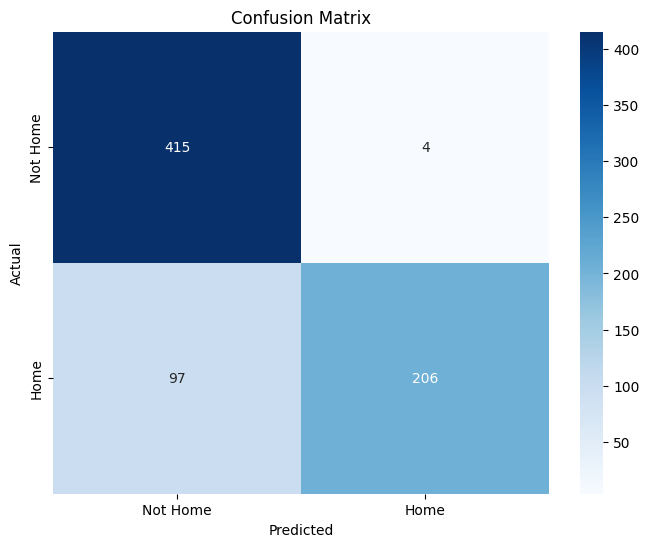

{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
MCC: 0.7283947603334497
accuracy: 0.8601108033240997
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       419
           1       0.98      0.68      0.80       303

    accuracy                           0.86       722
   macro avg       0.90      0.84      0.85       722
weighted avg       0.88      0.86      0.85       722



In [8]:
# Predicting on the test data
y_train_pred = model_rf.predict(X_train)

# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_train, y_train_pred)
accuracy = accuracy_score(y_train, y_train_pred)
classification_report_output = classification_report(y_train, y_train_pred)

cm = confusion_matrix(y_train, y_train_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

### Model without Weather Data:

In [9]:
# Splitting into features and target variable
X_train = train_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam','Temperature', 'Humidity', 'WindDirection', 'Precipitation', 'WindSpeed', 
                                   'WeatherCode_Clear', 'WeatherCode_Clouds', 'WeatherCode_Drizzle', 'WeatherCode_Fog', 'WeatherCode_Haze', 'WeatherCode_Mist', 'WeatherCode_Rain', 'WeatherCode_Snow'])
y_train = train_data['FTR']
X_test = test_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam','Temperature', 'Humidity', 'WindDirection', 'Precipitation', 'WindSpeed', 
                                   'WeatherCode_Clear', 'WeatherCode_Clouds', 'WeatherCode_Drizzle', 'WeatherCode_Fog', 'WeatherCode_Haze', 'WeatherCode_Mist', 'WeatherCode_Rain', 'WeatherCode_Snow'])
y_test = test_data['FTR']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((722, 38), (722,), (350, 38), (350,))

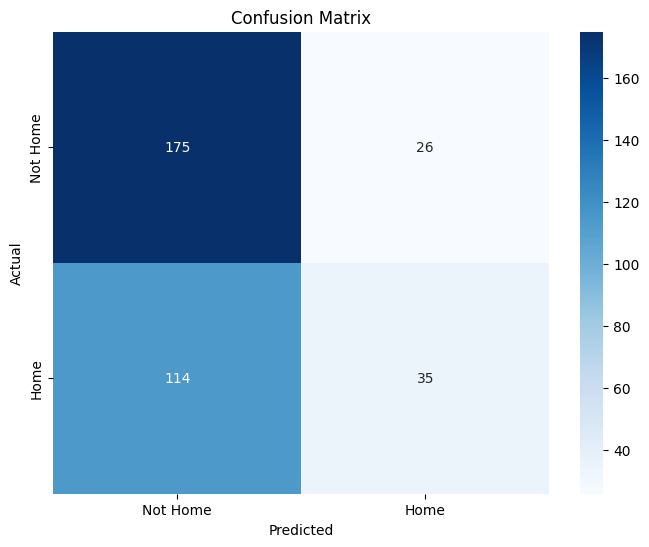

{'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 50}
MCC: 0.13756865588984718
accuracy: 0.6
              precision    recall  f1-score   support

           0       0.61      0.87      0.71       201
           1       0.57      0.23      0.33       149

    accuracy                           0.60       350
   macro avg       0.59      0.55      0.52       350
weighted avg       0.59      0.60      0.55       350



In [10]:
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': range(3,8),
    'min_samples_split': range(2,9),
    'min_samples_leaf': range(2,9)
    # 'bootstrap': [True, False]
}

# Using GridSearchCV to find the best hyperparameters (with weather data)
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Best parameters from GridSearch
best_params = grid_search_rf.best_params_

# Building the Random Forest model with the best parameters
model_rf = RandomForestClassifier(**best_params, random_state=42)
model_rf.fit(X_train, y_train)

# Predicting on the test data
y_pred = model_rf.predict(X_test)

# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [11]:
pd.DataFrame(y_pred,columns=['LR_y_pred']).to_csv('2.RF_y_pred_without_weather.csv')

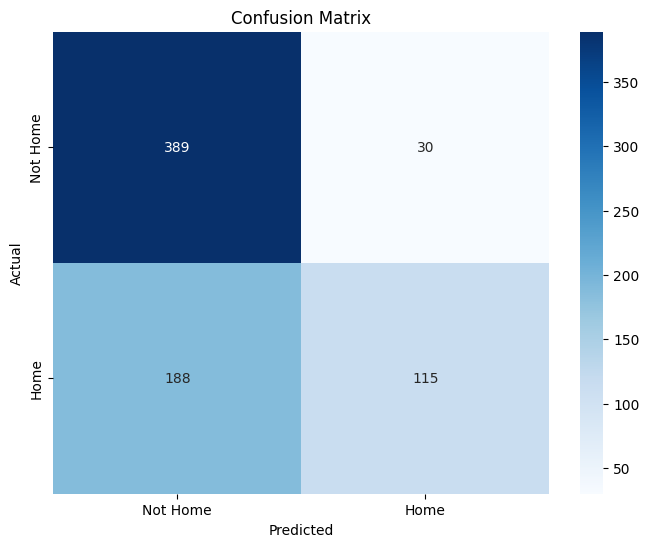

{'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 50}
MCC: 0.37933331297925343
accuracy: 0.6980609418282548
              precision    recall  f1-score   support

           0       0.67      0.93      0.78       419
           1       0.79      0.38      0.51       303

    accuracy                           0.70       722
   macro avg       0.73      0.65      0.65       722
weighted avg       0.72      0.70      0.67       722



In [12]:
# Predicting on the test data
y_train_pred = model_rf.predict(X_train)

# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_train, y_train_pred)
accuracy = accuracy_score(y_train, y_train_pred)
classification_report_output = classification_report(y_train, y_train_pred)

cm = confusion_matrix(y_train, y_train_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)